# Assignment Lab 4.2: Model Evaluation, Cross-Validation, and Hyperparameter Tuning

**Course 02: Introduction to Machine Learning for Cybersecurity**  
**Module 04: Model Evaluation and Tuning**

## Lab Goal
In this assignment, you will evaluate and improve a machine learning classification model using the Credit Card Fraud Detection dataset.

You will practice:

- Training a classification model
- Evaluating accuracy, precision, recall, and F1 score
- Interpreting a confusion matrix
- Creating an ROC curve and calculating AUC-ROC
- Applying cross-validation
- Experimenting with hyperparameter tuning

## Dataset
Use the provided dataset:

`creditcard.csv`

## Important Note
The target variable is `Class`.

- `Class = 0` means normal transaction
- `Class = 1` means fraudulent transaction

This dataset is highly imbalanced, so accuracy alone may not be enough to evaluate model performance.


## Step 1: Import Libraries

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Classification model
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

## Step 2: Load the Dataset

Update the file path if your dataset is saved in a different location.


In [2]:
# Load dataset
# Change the file path if needed

df = pd.read_csv("../../../datasets/creditcard.csv")

# Display first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 3: Explore the Dataset

In [3]:
# Display dataset shape
print("Dataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Review class distribution
print("\nClass distribution:")
print(df["Class"].value_counts())

print("\nClass distribution percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

# Display summary statistics
df.describe()

Dataset shape: (284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## Step 4: Define Features and Target

The target variable is `Class`.

- `0` = normal transaction
- `1` = fraudulent transaction


In [4]:
# Define features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (284807, 30)
Target shape: (284807,)


## Step 5: Split the Dataset

Split the data into training and testing sets.

Use `stratify=y` to preserve the same normal/fraud distribution in both sets.


In [5]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (227845, 30)
Testing set shape: (56962, 30)

Training target distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing target distribution:
Class
0    56864
1       98
Name: count, dtype: int64


## Step 6: Scale the Data

Some models perform better when numerical features are scaled.


In [6]:
# Scale the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (227845, 30)
Scaled testing data shape: (56962, 30)


## Step 7: Train a Classification Model

Choose and train at least one classification model.

Examples:
- Logistic Regression
- Decision Tree
- Random Forest


In [7]:
# Create the model
# Logistic Regression with class_weight="balanced" to account for the
# heavy class imbalance (fraud is the rare positive class).

model = LogisticRegression(max_iter=1000, class_weight="balanced")

# Train the model on the scaled training data
model.fit(X_train_scaled, y_train)

print("Model training complete.")

Model training complete.


## Step 8: Generate Predictions

Use your trained model to predict outcomes on the testing dataset.


In [8]:
# Generate predictions on the test set

y_pred = model.predict(X_test_scaled)

# Display first 10 predictions
print(y_pred[:10])

[0 0 0 0 1 0 0 0 0 0]


## Step 9: Evaluate Model Performance

Calculate accuracy, precision, recall, and F1 score.


In [9]:
# Calculate evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9755275446789088
Precision: 0.06097560975609756
Recall: 0.9183673469387755
F1 Score: 0.11435832274459974

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



## Step 10: Confusion Matrix

Create and interpret a confusion matrix.


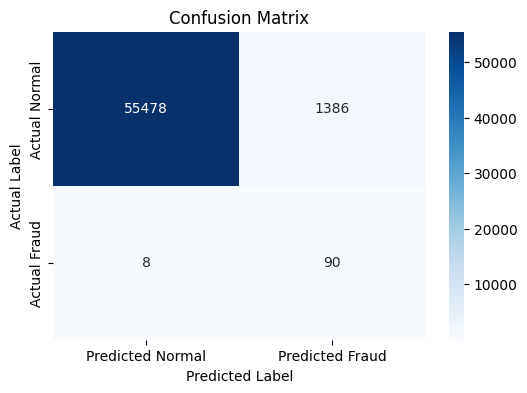

[[55478  1386]
 [    8    90]]


In [10]:
# Create a confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Fraud"],
    yticklabels=["Actual Normal", "Actual Fraud"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print(cm)

## Step 11: ROC Curve and AUC-ROC

Generate an ROC curve and calculate AUC-ROC.

Note: Your model must support probability predictions using `predict_proba()`.


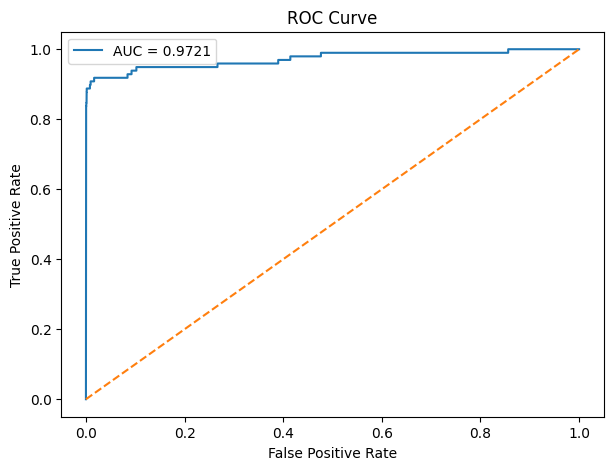

AUC-ROC Score: 0.9720834996210077


In [11]:
# Generate probabilities for the positive class (fraud)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculate AUC-ROC
auc_score = roc_auc_score(y_test, y_prob)

# Create ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("AUC-ROC Score:", auc_score)

## Step 12: Cross-Validation

Apply K-Fold Cross-Validation to estimate model reliability.


In [12]:
# Apply K-Fold cross-validation (scored on F1 because of class imbalance)

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean F1 score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation F1 scores: [0.12067436 0.10683761 0.11206226 0.11575563 0.12111293]
Mean F1 score: 0.1152885553958722
Standard deviation: 0.00538471690656991


## Step 13: Hyperparameter Tuning

Use GridSearchCV to test different model settings.

Example for Logistic Regression:
- C: controls regularization strength


In [13]:
# Define a parameter grid for Logistic Regression
# C controls regularization strength.

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear"]
}

# Create GridSearchCV, optimizing F1 because of the class imbalance
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced"),
    param_grid,
    cv=3,
    scoring="f1"
)

# Fit GridSearchCV
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1 score:", grid_search.best_score_)

Best parameters: {'C': 0.01, 'solver': 'liblinear'}
Best cross-validation F1 score: 0.11745465484260424


## Step 14: Evaluate the Tuned Model

Use the best model from GridSearchCV to evaluate performance on the testing set.


In [14]:
# Evaluate the tuned model

best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test_scaled)

print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned))

print("Tuned Model Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Tuned Model Confusion Matrix:
[[55496  1368]
 [    8    90]]


## Step 15: Compare Original and Tuned Models

Create a comparison table for model performance.


In [15]:
# Create a comparison table of the original vs tuned model

comparison = pd.DataFrame({
    "Model": ["Original Model", "Tuned Model"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_tuned)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_tuned)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Original Model,0.975528,0.060976,0.918367,0.114358
1,Tuned Model,0.975844,0.061728,0.918367,0.115681


## Step 16: Interpretation Questions

Answer the following questions in complete sentences.

### 1. What was the model accuracy?

The Logistic Regression model achieved an accuracy of approximately **97.55%** on the test set (97.58% after tuning).

### 2. Why might accuracy alone be misleading for this dataset?

Because the data is highly imbalanced — only about **0.17%** of the 284,807 transactions are fraudulent. A trivial model that predicts "normal" for everything would still be ~99.8% accurate while detecting no fraud at all, so accuracy gives a falsely reassuring picture and must be read alongside precision, recall, and F1.

### 3. What do precision and recall tell us in fraud detection?

Recall (**≈ 0.92**) measures how much of the actual fraud we caught — the model detected 90 of the 98 fraud cases. Precision (**≈ 0.06**) measures how reliable a fraud flag is — only ~6% of flagged transactions were truly fraud. In fraud detection we usually favor high recall (missing fraud is expensive and risky), but low precision means many false alarms for analysts to triage.

### 4. What does the confusion matrix show about the model's predictions?

```
                 Predicted Normal   Predicted Fraud
Actual Normal         55478              1386   (false positives)
Actual Fraud              8 (false neg)    90   (true positives)
```

The model caught **90 of 98** frauds (only 8 false negatives) but produced **1,386 false positives** — it errs strongly on the side of catching fraud at the cost of flagging many legitimate transactions.

### 5. Did cross-validation improve confidence in the model's reliability?

Yes. 5-fold cross-validation produced F1 scores of roughly **0.107–0.121** with a mean of **~0.115** and a very small standard deviation (**~0.005**). The consistency across folds shows the result is stable and not an artifact of one lucky train/test split.

### 6. Did hyperparameter tuning improve model performance?

Only slightly. `GridSearchCV` chose `C = 0.01`, raising F1 from **0.1144 → 0.1157**, accuracy from 97.55% → 97.58%, and reducing false positives from 1,386 to 1,368 while recall stayed at 90/98. Tuning `C` alone was not enough to materially change performance; a different model or resampling strategy would likely have more impact.

### 7. How can evaluation metrics support cybersecurity and fraud detection systems?

They let teams pick an operating point that fits the real cost of errors: recall to minimize missed threats, precision / false-positive counts to gauge analyst workload, and AUC-ROC (**≈ 0.97**) to confirm the model separates fraud from normal activity well overall. This converts a model into a tunable risk-vs-effort decision instead of a single accuracy figure.

### 8. What are some limitations of machine learning models in cybersecurity environments?

- **Severe class imbalance** makes rare attacks hard to learn and easy to overlook.
- **Low precision** can overwhelm analysts with false positives ("alert fatigue").
- **Concept drift** — attackers change tactics, so models trained on past data degrade over time.
- **Anonymized / limited features** (here, PCA components V1–V28) reduce interpretability and explainability.
- Models can be **evaded or poisoned** by adversaries, and they don't generalize automatically to new, unseen attack types.

## Submission Checklist

Before submitting, make sure:

- All code cells run without errors
- Your dataset path is correct
- Model training is completed
- Evaluation metrics are displayed
- Confusion matrix visualization is included
- ROC curve visualization is included
- Cross-validation results are included
- Hyperparameter tuning results are included
- Interpretation questions are answered
- Completed `.ipynb` notebook is downloaded and submitted in Canvas
